In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score

# load data
data = pd.read_csv("spambase.data", header=None)

# features and label
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# same 75/25 split as Problem 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


k_values = [1, 3, 5, 7, 9, 11, 15, 21]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

print("\nk      Accuracy     Error        Precision    Recall")

for k in k_values:
    knn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_validate(
        knn_model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall"]
    )

    acc = np.mean(scores["test_accuracy"])
    err = 1 - acc
    prec = np.mean(scores["test_precision"])
    rec = np.mean(scores["test_recall"])

    cv_results.append((k, acc, err, prec, rec))
    print(f"{k:<7}{acc:<13.4f}{err:<13.4f}{prec:<13.4f}{rec:<13.4f}")

best_k = min(cv_results, key=lambda x: x[2])[0]

print("\nBest k:", best_k)



k      Accuracy     Error        Precision    Recall
1      0.9067       0.0933       0.8844       0.8779       
3      0.9070       0.0930       0.8872       0.8749       
5      0.9087       0.0913       0.9010       0.8631       
7      0.9072       0.0928       0.8991       0.8617       
9      0.9020       0.0980       0.8936       0.8528       
11     0.9029       0.0971       0.8959       0.8528       
15     0.8957       0.1043       0.8969       0.8308       
21     0.8904       0.1096       0.8961       0.8175       

Best k: 5


In [8]:

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=10000, random_state=42))
])

lda_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

knn_final = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

models = {
    "Logistic Regression": log_model,
    "LDA": lda_model,
    "kNN": knn_final
}

for model in models.values():
    model.fit(X_train, y_train)

def evaluate(model, X_data, y_data):
    y_pred = model.predict(X_data)
    acc = accuracy_score(y_data, y_pred)
    err = 1 - acc
    prec = precision_score(y_data, y_pred, zero_division=0)
    rec = recall_score(y_data, y_pred, zero_division=0)
    return acc, err, prec, rec

print("\nModel                 Dataset    Accuracy     Error        Precision    Recall")

test_summary = []

for name, model in models.items():
    train_acc, train_err, train_prec, train_rec = evaluate(model, X_train, y_train)
    test_acc, test_err, test_prec, test_rec = evaluate(model, X_test, y_test)

    print(f"{name:<22}Train      {train_acc:<13.4f}{train_err:<13.4f}{train_prec:<13.4f}{train_rec:<13.4f}")
    print(f"{name:<22}Test       {test_acc:<13.4f}{test_err:<13.4f}{test_prec:<13.4f}{test_rec:<13.4f}")

    test_summary.append((name, test_acc, test_err, test_prec, test_rec))

best_model = max(test_summary, key=lambda x: x[1])[0]
worst_model = min(test_summary, key=lambda x: x[1])[0]



Model                 Dataset    Accuracy     Error        Precision    Recall
Logistic Regression   Train      0.9293       0.0707       0.9285       0.8889       
Logistic Regression   Test       0.9279       0.0721       0.9304       0.8833       
LDA                   Train      0.8910       0.1090       0.9183       0.7940       
LDA                   Test       0.8844       0.1156       0.9105       0.7841       
kNN                   Train      0.9342       0.0658       0.9249       0.9065       
kNN                   Test       0.8992       0.1008       0.8789       0.8634       


AUC: 0.9727055536945627


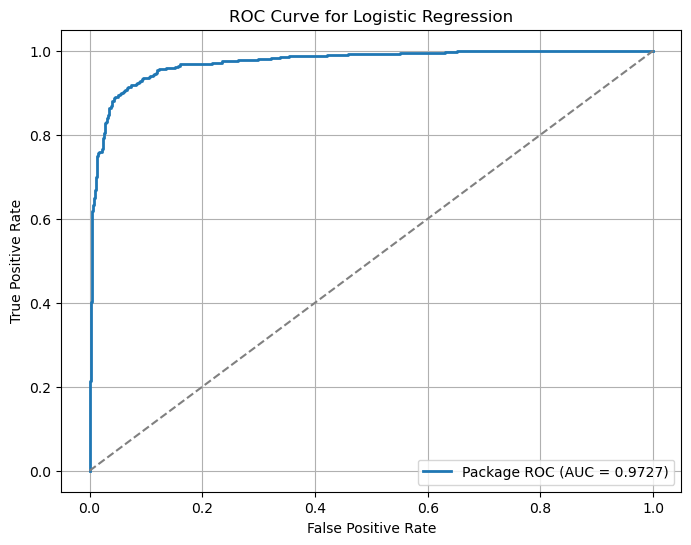

In [4]:


log_probs = log_model.predict_proba(X_test)[:, 1]

fpr_pkg, tpr_pkg, thresholds_pkg = roc_curve(y_test, log_probs)
auc_value = roc_auc_score(y_test, log_probs)

print("AUC:", auc_value)

plt.figure(figsize=(8, 6))
plt.plot(fpr_pkg, tpr_pkg, label=f"Package ROC (AUC = {auc_value:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


Threshold   FPR         TPR
0.0         1.0000      1.0000      
0.1         0.3085      0.9802      
0.2         0.1650      0.9692      
0.3         0.1019      0.9339      
0.4         0.0660      0.9075      
0.5         0.0430      0.8833      
0.6         0.0344      0.8502      
0.7         0.0273      0.8062      
0.8         0.0158      0.7489      
0.9         0.0043      0.6189      
1.0         0.0000      0.0000      


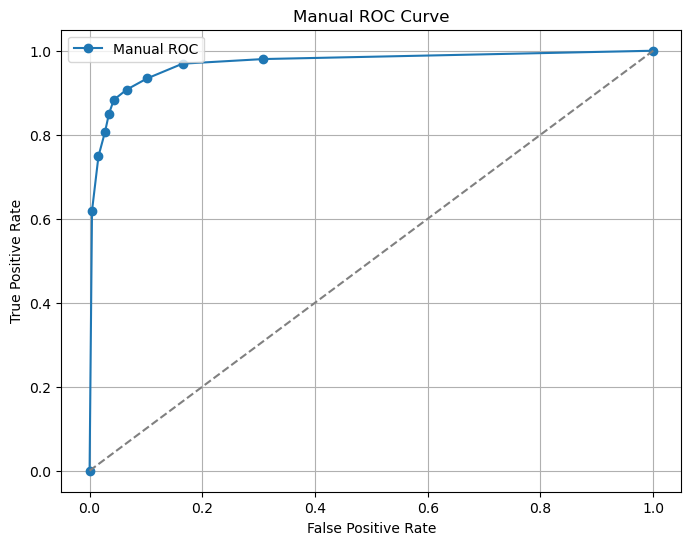

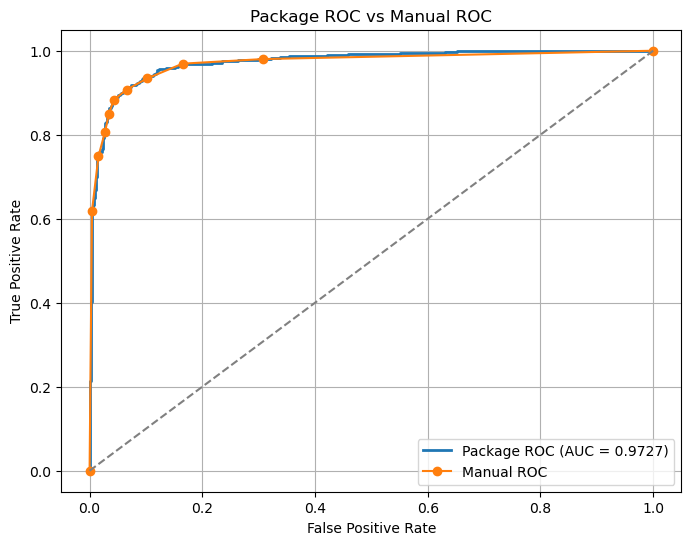

In [9]:

thresholds = np.arange(0, 1.1, 0.1)
manual_fpr = []
manual_tpr = []

print("\nThreshold   FPR         TPR")

for t in thresholds:
    preds = (log_probs >= t).astype(int)

    TP = np.sum((y_test == 1) & (preds == 1))
    TN = np.sum((y_test == 0) & (preds == 0))
    FP = np.sum((y_test == 0) & (preds == 1))
    FN = np.sum((y_test == 1) & (preds == 0))

    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0

    manual_fpr.append(fpr)
    manual_tpr.append(tpr)

    print(f"{t:<12.1f}{fpr:<12.4f}{tpr:<12.4f}")

plt.figure(figsize=(8, 6))
plt.plot(manual_fpr, manual_tpr, marker="o", label="Manual ROC")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# compare package ROC and manual ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_pkg, tpr_pkg, label=f"Package ROC (AUC = {auc_value:.4f})", linewidth=2)
plt.plot(manual_fpr, manual_tpr, marker="o", label="Manual ROC")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Package ROC vs Manual ROC")
plt.legend()
plt.grid(True)
plt.show()
